# Yearly Behavioral Perspective
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

Yearly behavioral segmentation, analyzing purchasing habits and travel behaviors.


## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import warnings
import umap

from sklearn.preprocessing import  MinMaxScaler

from sklearn.metrics import silhouette_score, silhouette_samples # new library
from sklearn.cluster import KMeans # new library
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.cm as cm


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_context("notebook")
sns.set_style("ticks")

In [131]:
df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

In [132]:
Behavioral_columns = df_AIAI_Master.columns.to_list()[-60:]

df_AIAI_Behavioral = df_AIAI_Master[Behavioral_columns].copy()
df_AIAI_Behavioral.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610
549612,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500
429460,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764.0,6097.0,30356.0,0.0,6110.0,0.0,0.0,16881.0,56823.0,0.0,1030.0,45760.0,0.000000,75.000000,86.666667,0.000000,8.695652,0.000000,0.0,80.952381,0.000000,0.000000,0.000000,100.000000,66.7543,-48.7079,30.3493,0.0000,6.1044,0.0000,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556
608370,73.0,81.0,42.0,143467.0,159407.0,83156.0,30.136986,30.864198,26.190476,82.0413,91.12,49.48,11.0,21.0,31.0,13.0,24.0,37.0,0.0,0.0,19.0,22.0,2.0,16.0,49255.0,35206.0,65665.0,37464.0,38224.0,45139.0,0.0,0.0,9285.0,53130.0,29241.0,23421.0,72.727273,52.380952,41.935484,0.000000,16.666667,0.000000,0.0,0.000000,10.526316,59.090909,0.000000,43.750000,-13.7374,-31.4985,65.6521,37.4562,38.2229,45.1288,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270
530508,39.0,43.0,89.0,126360.0,140400.0,99853.0,48.717949,48.837209,25.842697,126.3600,140.37,99.81,0.0,22.0,4.0,0.0,24.0,15.0,21.0,38.0,8.0,0.0,24.0,15.0,0.0,19731.0,5566.0,0.0,47106.0,54063.0,55404.0,73431.0,68327.0,0.0,40863.0,2122.0,0.000000,40.909091,100.000000,0.000000,25.000000,60.000000,0.0,34.210

# By Year

We only are going to select the variables related for the years.

In [133]:
df_AIAI_Behavioral_year = df_AIAI_Behavioral[df_AIAI_Behavioral.columns.to_list()[:12]].copy()
df_AIAI_Behavioral_year.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021
Loyalty#,,,,,,,,,,,,
480934,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72
549612,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10
429460,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58
608370,73.0,81.0,42.0,143467.0,159407.0,83156.0,30.136986,30.864198,26.190476,82.0413,91.12,49.48
530508,39.0,43.0,89.0,126360.0,140400.0,99853.0,48.717949,48.837209,25.842697,126.3600,140.37,99.81


In [134]:
df_AIAI_Behavioral_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Total_NumFlights_2019              15101 non-null  float64
 1   Total_NumFlights_2020              15101 non-null  float64
 2   Total_NumFlights_2021              15101 non-null  float64
 3   Total_DistanceKM_2019              15101 non-null  float64
 4   Total_DistanceKM_2020              15101 non-null  float64
 5   Total_DistanceKM_2021              15101 non-null  float64
 6   Perc_Flights_With_Companions_2019  15101 non-null  float64
 7   Perc_Flights_With_Companions_2020  15101 non-null  float64
 8   Perc_Flights_With_Companions_2021  15101 non-null  float64
 9   Dollar_Cost_Points_Remaining_2019  15101 non-null  float64
 10  Dollar_Cost_Points_Remaining_2020  15101 non-null  float64
 11  Dollar_Cost_Points_Remaining_2021  15101 non-null  fl

## Feature Selection

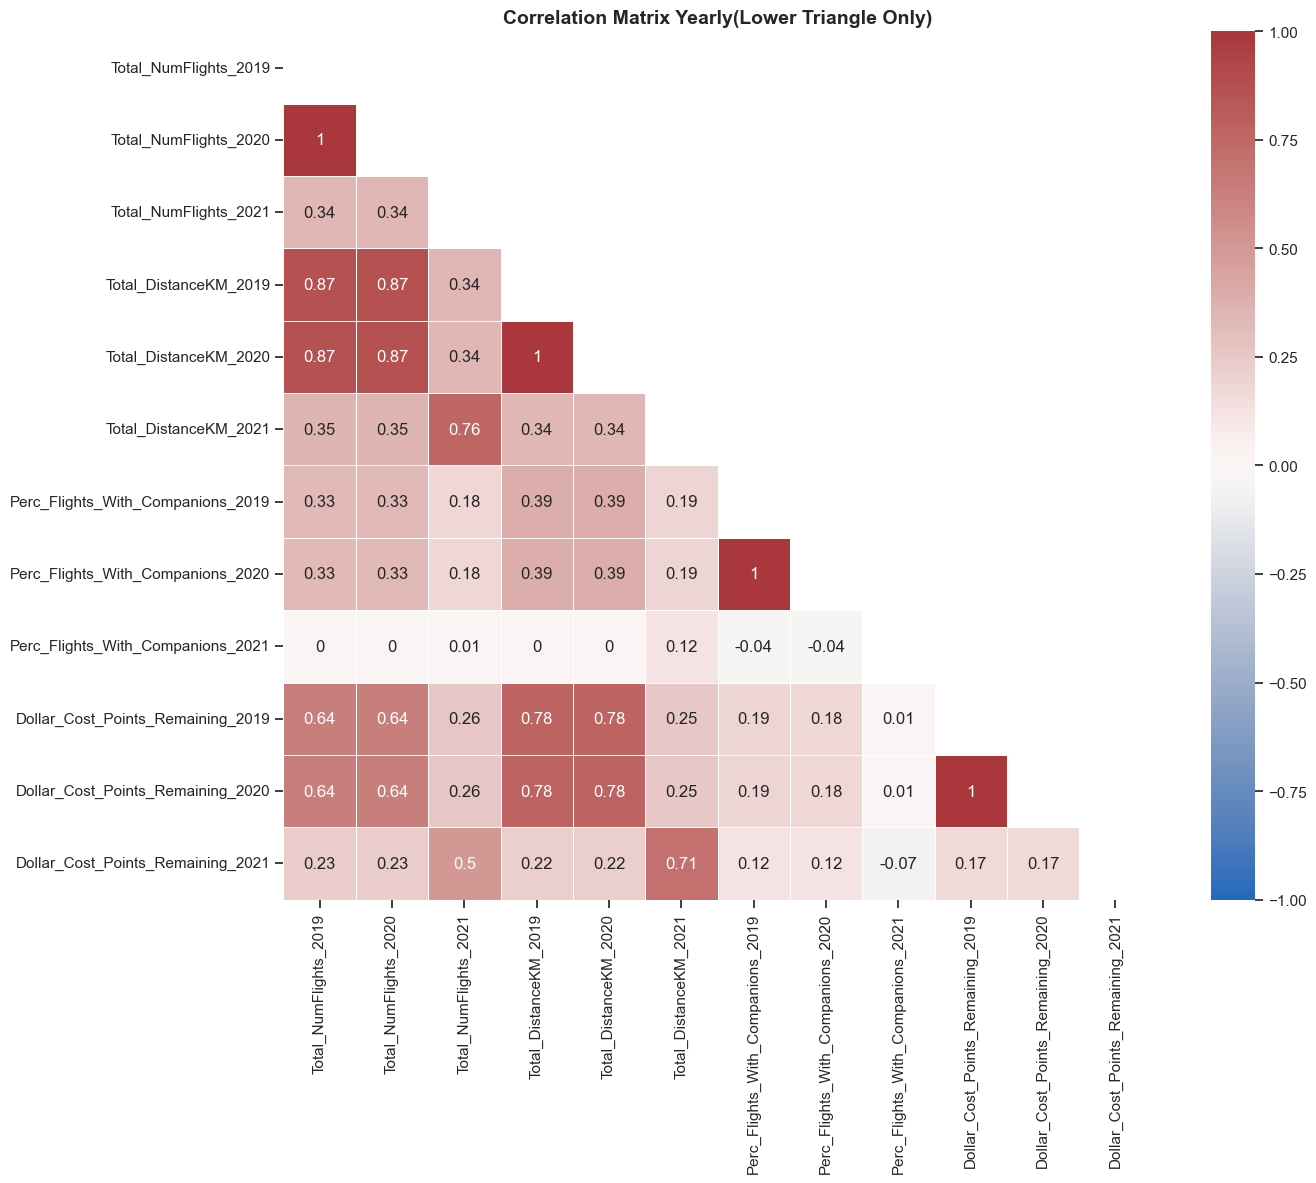

In [135]:
# Compute Pearson correlation
corr = df_AIAI_Behavioral_year.corr(method="pearson")
# Round to 2 decimals for cleaner display
corr = corr.round(2)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig = plt.figure(figsize=(15, 12))

sns.heatmap(data=corr, 
            annot=True, 
            mask=mask, #aply the mask
            vmin=-1, vmax=1, 
            center=0, # Center the colormap at zero
            square=True, # Make each cell square-shaped
            linewidths=.5, # Add lines between cells
            cmap='vlag' # Diverging color map
            )

plt.title("Correlation Matrix Yearly(Lower Triangle Only)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

The number of flights in 2020 and 2019 had a perfect positive correlation, also the distance on those  years, the percentage of companions on those years and the dollarcostpointsremaining, so we will discard one of the years since they have the same information to create the clusters. <br>
So we will discard 2019: total number of flighs, total distance, perc flights with companions and dollar cost points.  

In [136]:
# Drop 2019 columns due to high correlation with 2020
columns_to_drop = ['Total_NumFlights_2019', 'Total_DistanceKM_2019', 'Perc_Flights_With_Companions_2019', 'Dollar_Cost_Points_Remaining_2019']
df_AIAI_Behavioral_year = df_AIAI_Behavioral_year.drop(columns=columns_to_drop)

In [137]:
df_AIAI_Behavioral_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Total_NumFlights_2020              15101 non-null  float64
 1   Total_NumFlights_2021              15101 non-null  float64
 2   Total_DistanceKM_2020              15101 non-null  float64
 3   Total_DistanceKM_2021              15101 non-null  float64
 4   Perc_Flights_With_Companions_2020  15101 non-null  float64
 5   Perc_Flights_With_Companions_2021  15101 non-null  float64
 6   Dollar_Cost_Points_Remaining_2020  15101 non-null  float64
 7   Dollar_Cost_Points_Remaining_2021  15101 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


We successfully deleted the 2019 columns due to high correlation with 2020.

## Missing Values

In [138]:
df_AIAI_Behavioral_year.isna().sum()

Total_NumFlights_2020                1471
Total_NumFlights_2021                1471
Total_DistanceKM_2020                1471
Total_DistanceKM_2021                1471
Perc_Flights_With_Companions_2020    1471
Perc_Flights_With_Companions_2021    1471
Dollar_Cost_Points_Remaining_2020    1471
Dollar_Cost_Points_Remaining_2021    1471
dtype: int64

We identified customers with missing values (no transactions) and we are going to filtered them out to ensure complete data for clustering algorithms. We are going to put this group of no transactions in the final cluster analysis. 


In [139]:
# Filter rows with any missing values into a new dataframe and add No_transactions (count of missing per row)
df_AIAI_Y_Behavioral_classified = df_AIAI_Behavioral_year[df_AIAI_Behavioral_year.isna().any(axis=1)].copy()

df_AIAI_Y_Behavioral_classified['Final_Cluster'] = 'No_transactions'

# Remove those observations from the original dataframe
df_AIAI_Behavioral_year = df_AIAI_Behavioral_year.drop(df_AIAI_Y_Behavioral_classified.index)


df_AIAI_Y_Behavioral_classified.head()


,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Final_Cluster
Loyalty#,,,,,,,,,
201574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
834891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
329382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
357549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
283314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions


## Outliers 

To ensure model robustness, we implement an outlier handling strategy using the Interquartile Range (IQR) method. Data points falling beyond 3 times the IQR are identified as extreme outliers. Furthermore, for variables lacking defined physical or logical boundaries, we apply capping (3 times the IQR) to limit extreme values and reduce their influence on the clustering results.

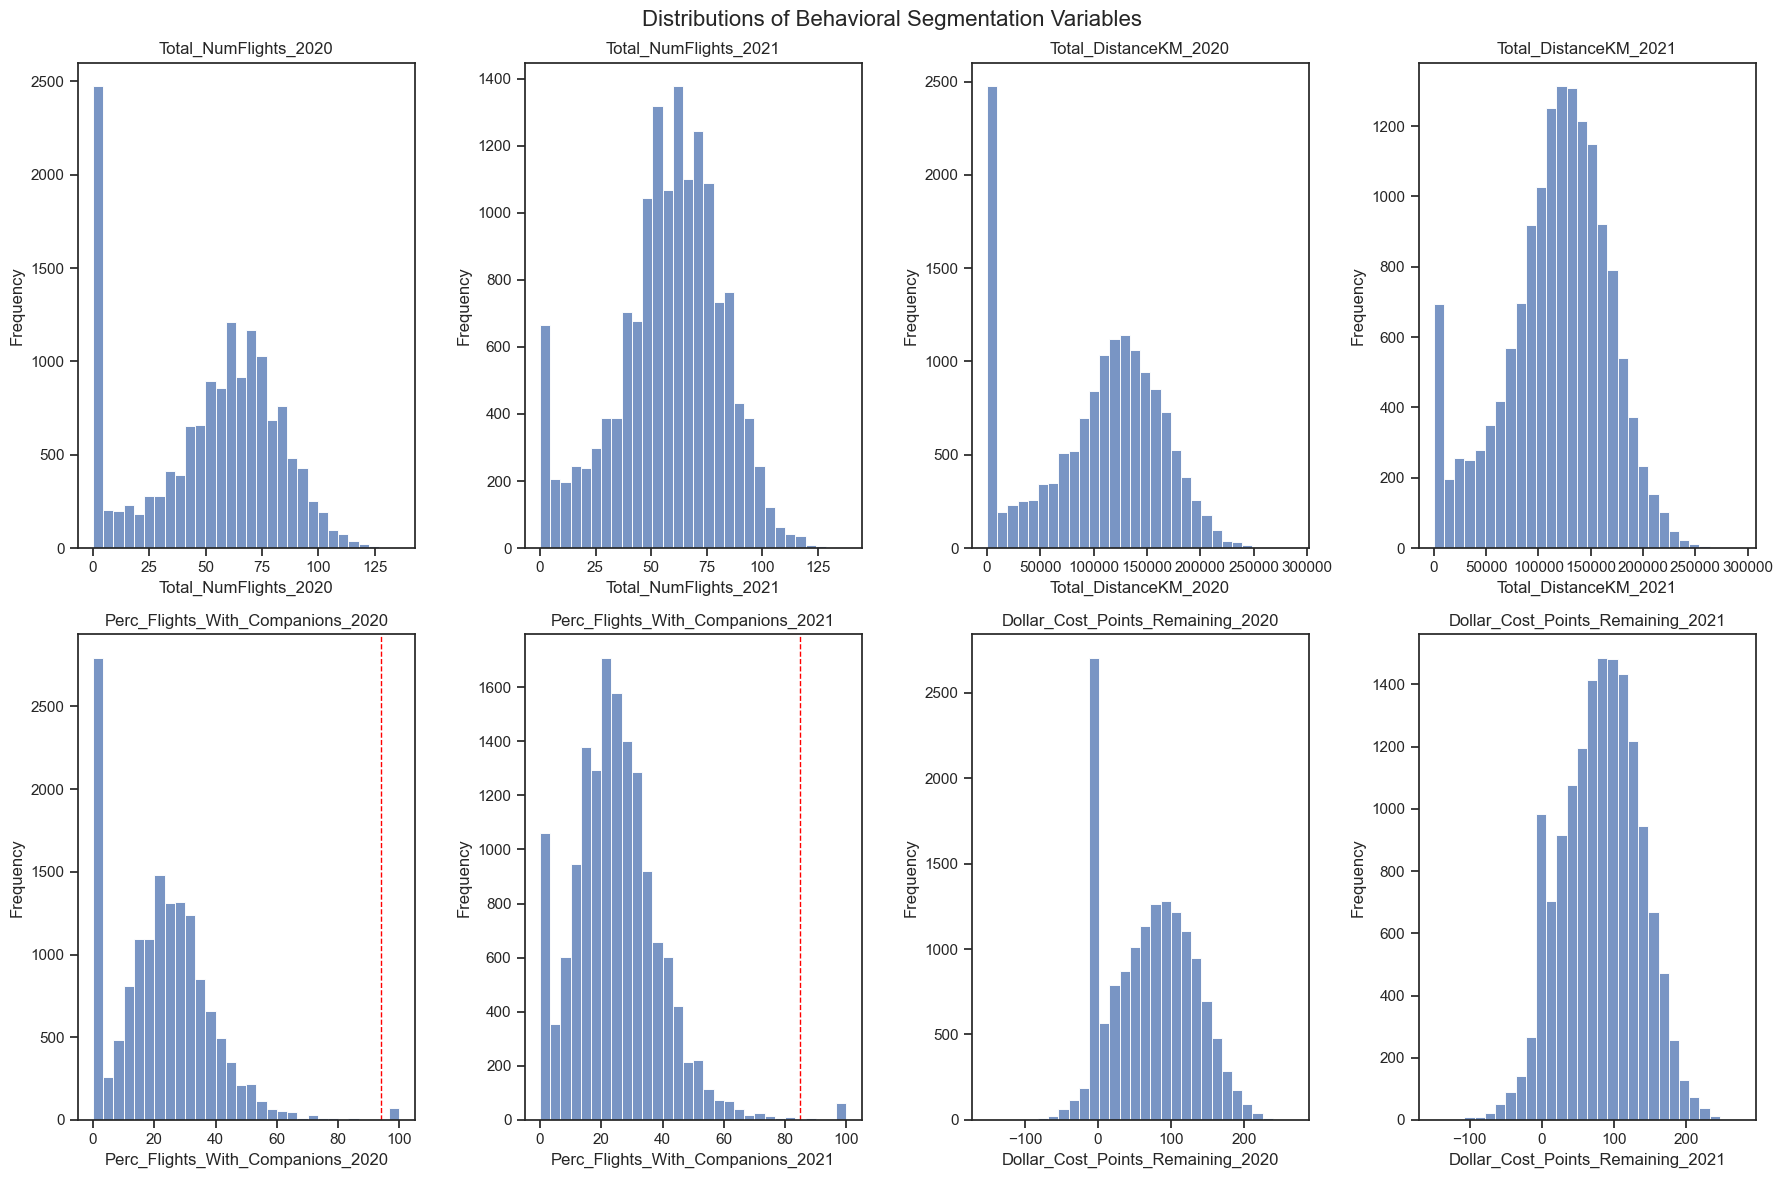

In [140]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_Behavioral_year.columns):

    data = df_AIAI_Behavioral_year[col]

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Behavioral Segmentation Variables", fontsize=16)
plt.tight_layout()
plt.show()

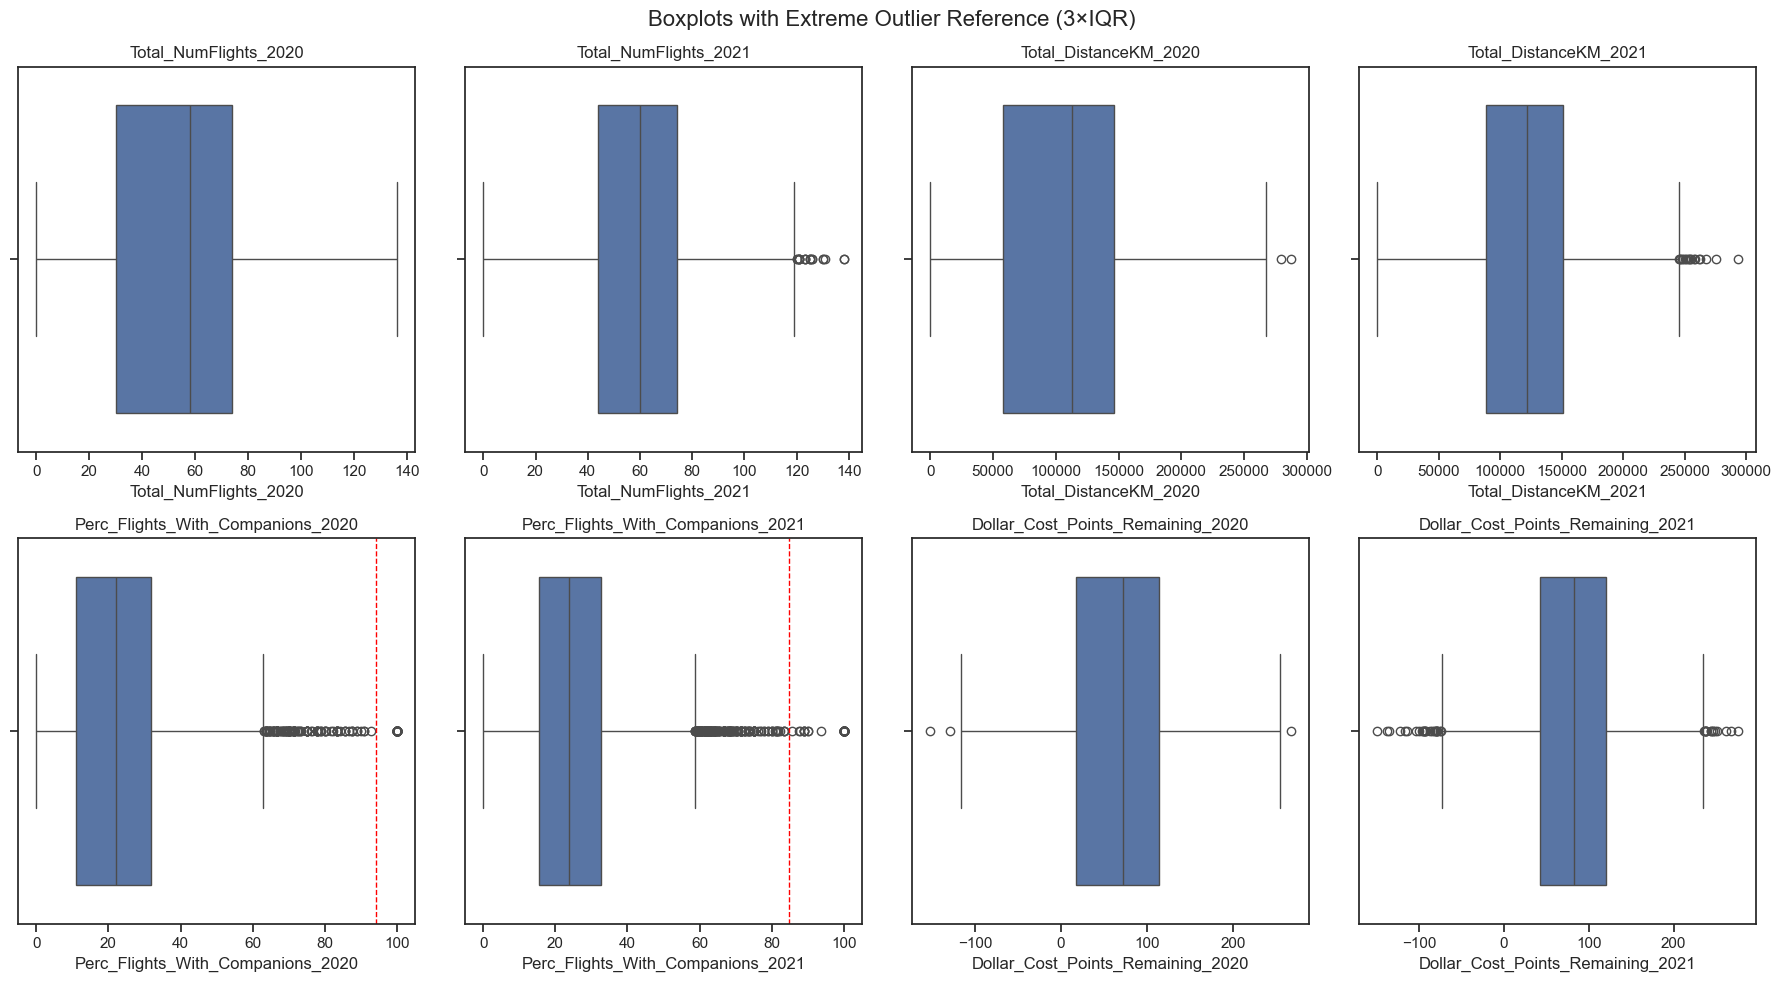

In [141]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_Behavioral_year.columns):
    
    data = df_AIAI_Behavioral_year[col]
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()

Perc flight with companions 2020 and 2021 are the only variables with extreme outliers.

We are not going to take out any outlier beacause this variables have limit logic defined, they stop in 100.

## Scaling

We are going to use Min-Max scaling (-1, 1) to normalize these yearly metrics.

In [142]:
scaler = MinMaxScaler(feature_range=(-1, 1))
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_AIAI_Behavioral_year),
    index=df_AIAI_Behavioral_year.index,
    columns=df_AIAI_Behavioral_year.columns
)

In [143]:
df_for_modeling.head()

,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021
Loyalty#,,,,,,,,
480934,-0.058824,-0.014493,-0.101322,0.723197,-0.406250,-0.411765,0.226085,0.470458
549612,0.455882,0.318841,-0.009243,-0.182000,-0.838384,-0.626374,0.084835,-0.191563
429460,-0.117647,-0.913043,-0.243667,-0.838942,-0.300000,-1.000000,0.105484,-0.184596
608370,0.191176,-0.391304,0.110715,-0.432093,-0.382716,-0.476190,0.160134,-0.062662
530508,-0.367647,0.289855,-0.021722,-0.318063,-0.023256,-0.483146,0.394993,0.174286


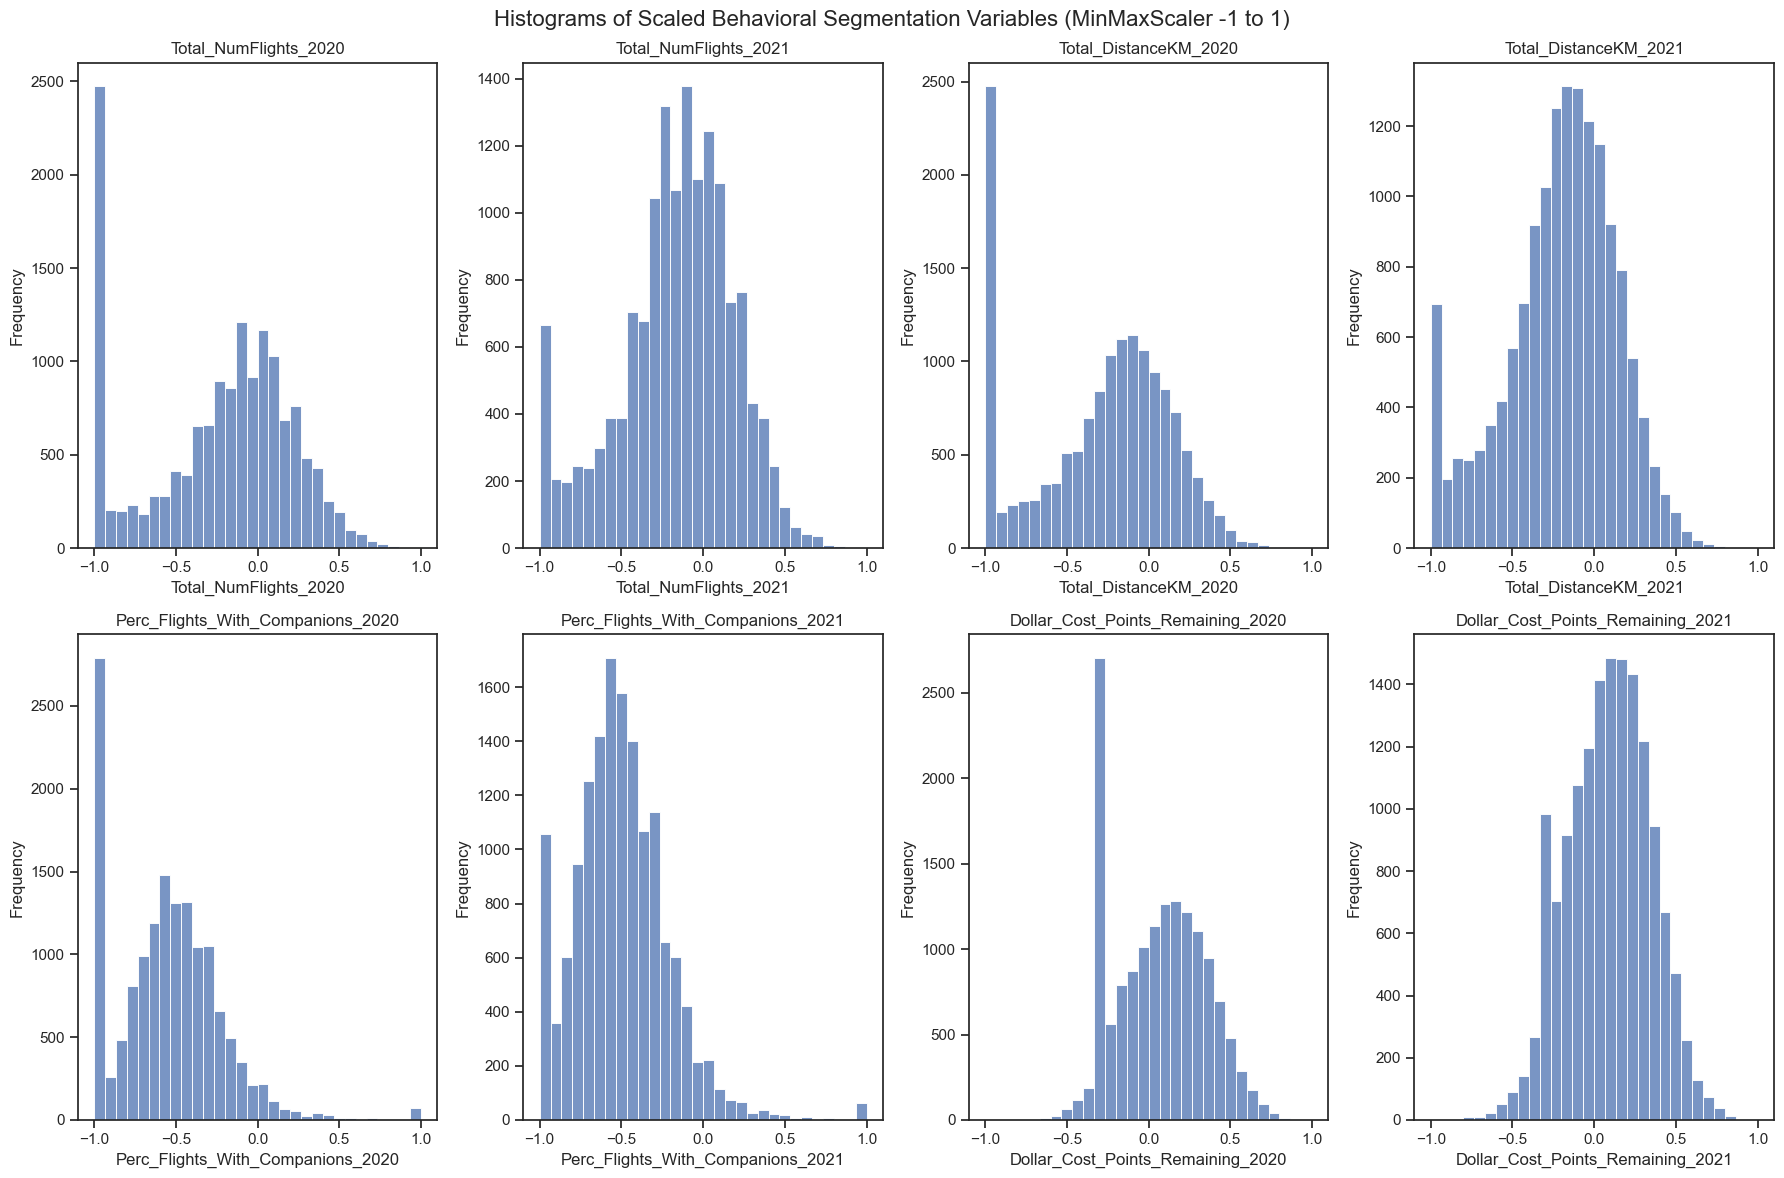

In [144]:
# Histograms of Scaled Variables
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, df_for_modeling.columns):
    sns.histplot(df_for_modeling[col], bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Histograms of Scaled Behavioral Segmentation Variables (MinMaxScaler -1 to 1)", fontsize=16)
plt.tight_layout()
plt.show()

This is how the variables look after scaling them. This is going to be important in the part of cluster profiling.

## Kmeans

K-Means clustering is used as the first unsupervised learning algorithm to segment customers based on their annual behavioral metrics.

We need to defined the numbers of cluster, we need to understand:

SST - Total variance of the dataset. 

SSW - Total variance within clusters.

SSB - Total variance between clusters.

R2 - measures how well a clustering structure explains the variation in the data- higher values indicate more distinct and internally cohesive clusters.

In [145]:
X = df_for_modeling.values

# Compute SST once (constant for all clusterings)
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

results = []

for n_clusters in range(2, 11):  # Test from 2 to 10 clusters
    kmclust = KMeans(n_clusters=n_clusters, init='k-means++', random_state=22)
    labels = kmclust.fit_predict(df_for_modeling)
    
    # ---- SSW ----
    ssw = kmclust.inertia_
    
    # ---- SSB ----
    ssb_iter = []
    for i in np.unique(labels):
        X_k = X[labels == i]
        ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))
    ssb_per_feature = np.sum(ssb_iter, axis=0)
    ssb = np.sum(ssb_per_feature, axis=0)
    
    # ---- Silhouette ----
    sil_score = silhouette_score(X, labels)
    
    results.append({
        'num_clusters': n_clusters,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'silhouette_score (Higher is better, −1 to +1)': sil_score,
        'r2 (Higher is better, 0 to 1)': ssb / sst,
        
        
    })

df_cluster_metrics = pd.DataFrame(results)

In [146]:
df_cluster_metrics

,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","silhouette_score (Higher is better, −1 to +1)","r2 (Higher is better, 0 to 1)"
0,2,8949.187994,5488.883353,0.396568,0.380167
1,3,8021.657726,6416.431143,0.365349,0.444411
2,4,6851.131082,7586.944656,0.220296,0.525482
3,5,6170.571521,8267.509176,0.192725,0.572619
4,6,5820.794943,8617.286377,0.174445,0.596845
5,7,5581.327994,8856.819010,0.164267,0.613435
6,8,5100.491436,9337.586982,0.165211,0.646734
7,9,4911.352824,9526.720153,0.161703,0.659834
8,10,4765.474393,9672.605107,0.153133,0.669938


Based on the results from the clustering metrics table, we are going to choose 5 and 8 clusters to create the segments. 

For 5 clusters:
- Silhouette Score: ~0.19 
- R²: ~0.57 (explains 57% of variance)
- Provides a balanced number of segments for interpretation.

For 8 clusters:
- Silhouette Score: ~0.17 
- R²: ~0.65 
- Offers more granularity for detailed customer segmentation.

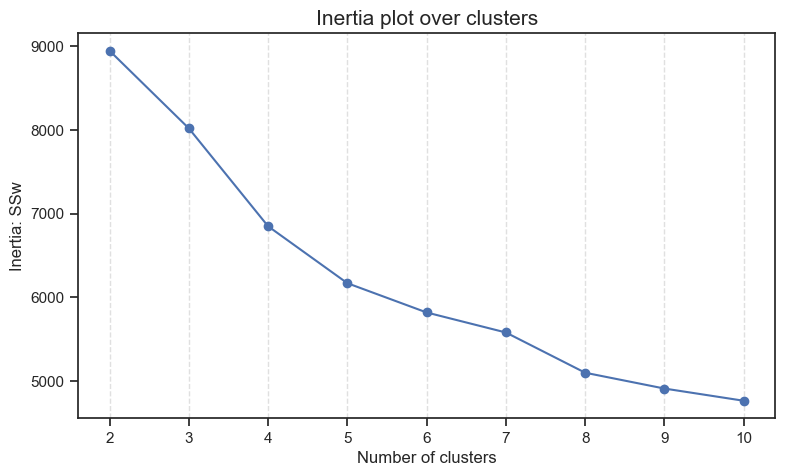

In [147]:
fig, ax = plt.subplots(figsize=(9,5))

range_clusters= list(range(2,11))
inertia= df_cluster_metrics['ssw (Lower is better, 0 to +∞)']
ax.plot(range_clusters, inertia, marker='o', zorder=2)
ax.set_xticks(list(range_clusters))

# draw vertical dashed background lines at each cluster number
for x in range_clusters:
    ax.axvline(x, color='lightgray', linestyle='--', linewidth=1, zorder=0, alpha=0.7)

ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

We selected both (5 and 8) to compare their profiling.

### K-mean 5

In [148]:
# final cluster solution with 5
number_clusters = 5
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(df_for_modeling)
km_labels

array([1, 1, 0, ..., 1, 1, 2], dtype=int32)

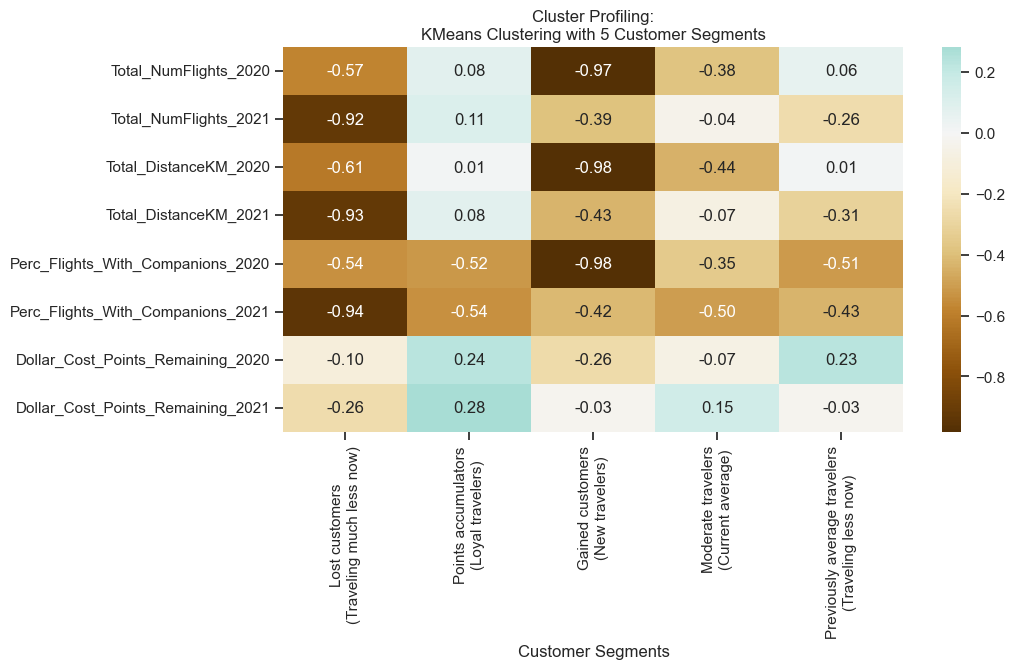

In [149]:
cluster_name_map = {
    0: "Lost customers\n(Traveling much less now)",
    1: "Points accumulators\n(Loyal travelers)",
    2: "Gained customers\n(New travelers)",
    3: "Moderate travelers\n(Current average)",
    4: "Previously average travelers\n(Traveling less now)"
}

df_concat_km5 = pd.concat(
    (df_for_modeling, pd.Series(km_labels, name='labels', index=df_for_modeling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))

# Compute cluster profiles
km_profile = df_concat_km5.groupby('labels').mean().T

# Rename cluster columns using your mapping
km_profile = km_profile.rename(columns=cluster_name_map)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 5 Customer Segments")
plt.show()

**Cluster Interpretations for KMeans with 5 Clusters:**

0. **Lost Customers**: Customers who have significantly reduced their travel frequency compared to previous years. They were more active travelers before but are now less engaged.

1. **Points Accumulators**: Consistent travelers who maintain steady flight activity and accumulate points regularly, indicating loyalty to the airline.

2. **Gained Customers**: New or reactivated travelers who previously had little to no travel activity but have started traveling at average levels recently.

3. **Moderate Travelers**: Customers who travel at moderate levels now, having increased from low activity in the past. They accumulate points based on their current travel patterns.

4. **Previously Average Travelers**: Customers who used to travel at average frequencies but have since decreased their activity. They may still hold accumulated points from previous travel periods.

In [150]:
df_concat_km5['cluster_name'] = df_concat_km5['labels'].map(cluster_name_map)

In [151]:
df_concat_km5['cluster_name'].value_counts()

cluster_name
Points accumulators\n(Loyal travelers)                4255
Previously average travelers\n(Traveling less now)    4009
Moderate travelers\n(Current average)                 3434
Gained customers\n(New travelers)                     2489
Lost customers\n(Traveling much less now)              914
Name: count, dtype: int64

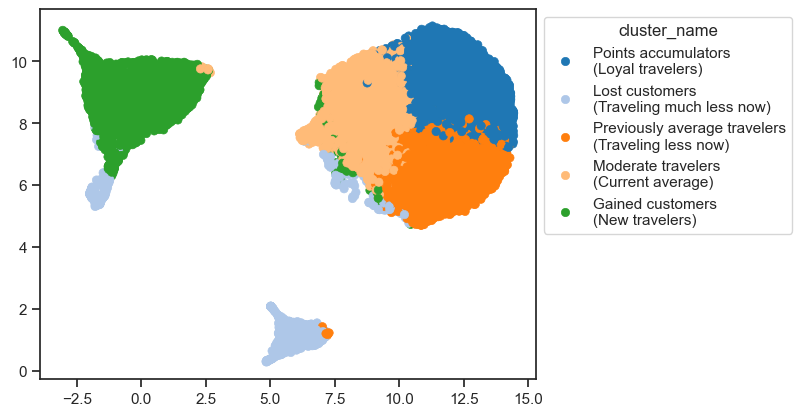

In [152]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat_km5['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

### K-mean 8

In [153]:
# final cluster solution with 8
number_clusters = 8
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(df_for_modeling)
km_labels

array([1, 5, 0, ..., 1, 1, 6], dtype=int32)

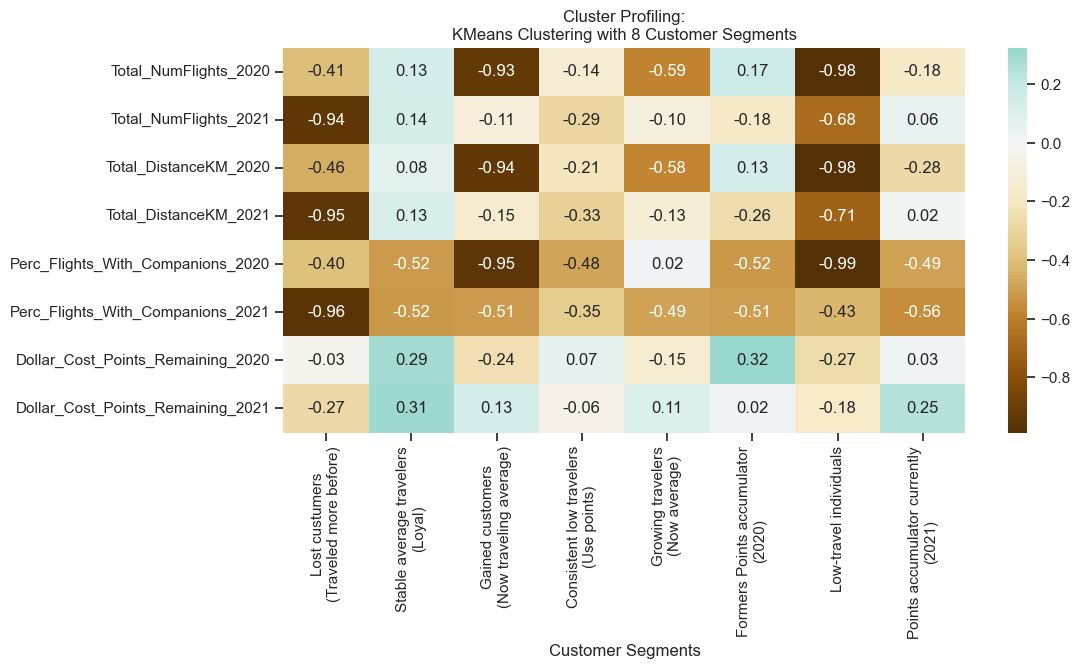

In [154]:
cluster_name_map_8 = {
    0: "Lost custumers\n(Traveled more before)",
    1: "Stable average travelers\n(Loyal)",
    2: "Gained customers\n(Now traveling average)",
    3: "Consistent low travelers\n(Use points)",
    4: "Growing travelers\n(Now average)",
    5: "Formers Points accumulator\n(2020)",
    6: "Low-travel individuals",
    7: "Points accumulator currently\n(2021)"
}
df_concat_km8 = pd.concat(
    (df_for_modeling, pd.Series(km_labels, name='labels', index=df_for_modeling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

km_profile = df_concat_km8.groupby('labels').mean().T

# Rename cluster columns
km_profile = km_profile.rename(columns=cluster_name_map_8)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 8 Customer Segments")
plt.show()

**Cluster Interpretations for KMeans with 8 Clusters:**

0. **Lost Customers**: Travelers who used to fly more frequently but have significantly reduced their travel now.

1. **Stable Average Travelers**: Loyal customers who maintain consistent average travel patterns over time.

2. **Gained Customers**: New or reactivated travelers who previously had minimal activity but now travel at average levels.

3. **Consistent Low Travelers**: Customers who travel steadily but at levels below the average, often utilizing accumulated points.

4. **Growing Travelers**: Individuals who previously traveled infrequently but have increased to average travel levels recently.

5. **Former Points Accumulators (2020)**: Customers who were actively accumulating points in 2020 but have since changed their behavior.

6. **Low-Travel Individuals**: People with consistently low travel activity across the observed periods.

7. **Current Points Accumulators (2021)**: Active travelers focused on accumulating points in 2021.

In [155]:
df_concat_km8['cluster_name'] = df_concat_km8['labels'].map(cluster_name_map_8)

In [156]:
df_concat_km8['cluster_name'].value_counts()

cluster_name
Points accumulator currently\n(2021)         3070
Formers Points accumulator\n(2020)           2681
Stable average travelers\n(Loyal)            2509
Consistent low travelers\n(Use points)       2346
Low-travel individuals                       1473
Gained customers\n(Now traveling average)    1448
Growing travelers\n(Now average)              914
Lost custumers\n(Traveled more before)        660
Name: count, dtype: int64

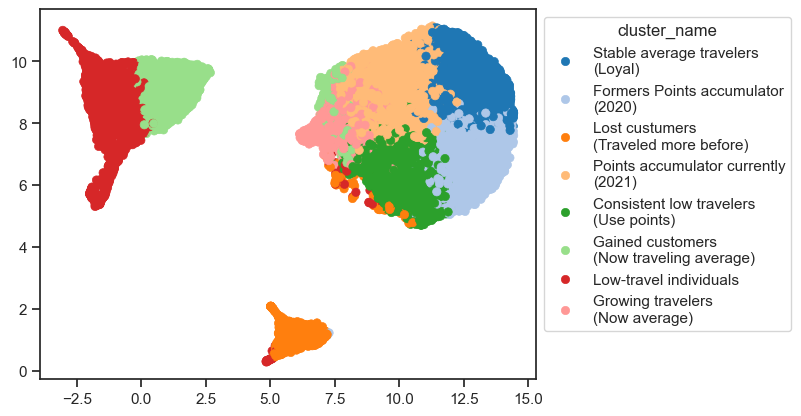

In [157]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat_km8['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Hierarchical

In addition to KMeans, hierarchical clustering is applied to further explore the structure of the data. Unlike partition-based methods, hierarchical clustering builds a hierarchy of clusters that allows observation of relationships between customer groups at different levels of granularity. This approach is useful for understanding similarities between clusters and provides complementary insights to the KMeans results.

In [158]:
linkage_matrix= linkage(df_for_modeling, method="ward")

In [159]:
linkage_matrix.shape

(15100, 4)

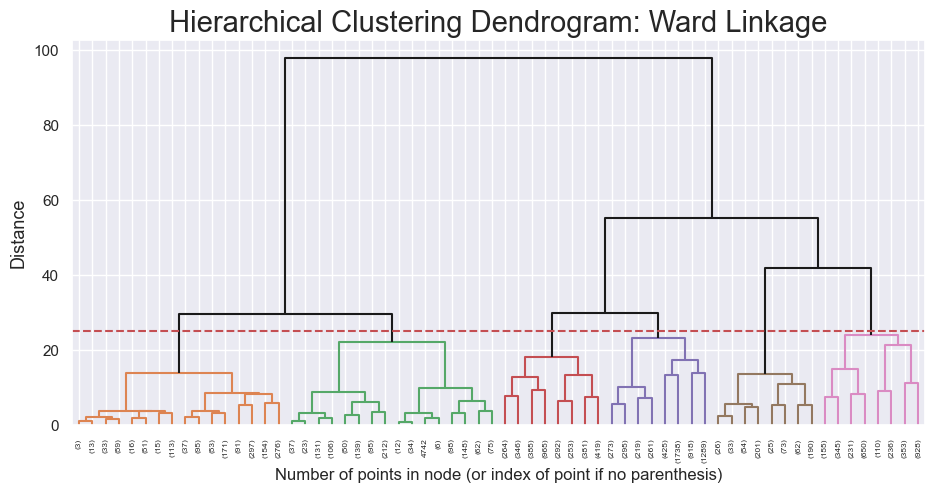

In [160]:
# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 25
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    # You can play with 'truncate_mode' and 'p' define what level the dendrogram shows
    # above_threshold_color='k' forces black color for the lines above the threshold)
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Distance', fontsize=13)
plt.show()

In [161]:
# Performing HC
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=6)
hc_labels = hclust.fit_predict(df_for_modeling)
hc_labels

array([1, 1, 3, ..., 1, 1, 5])

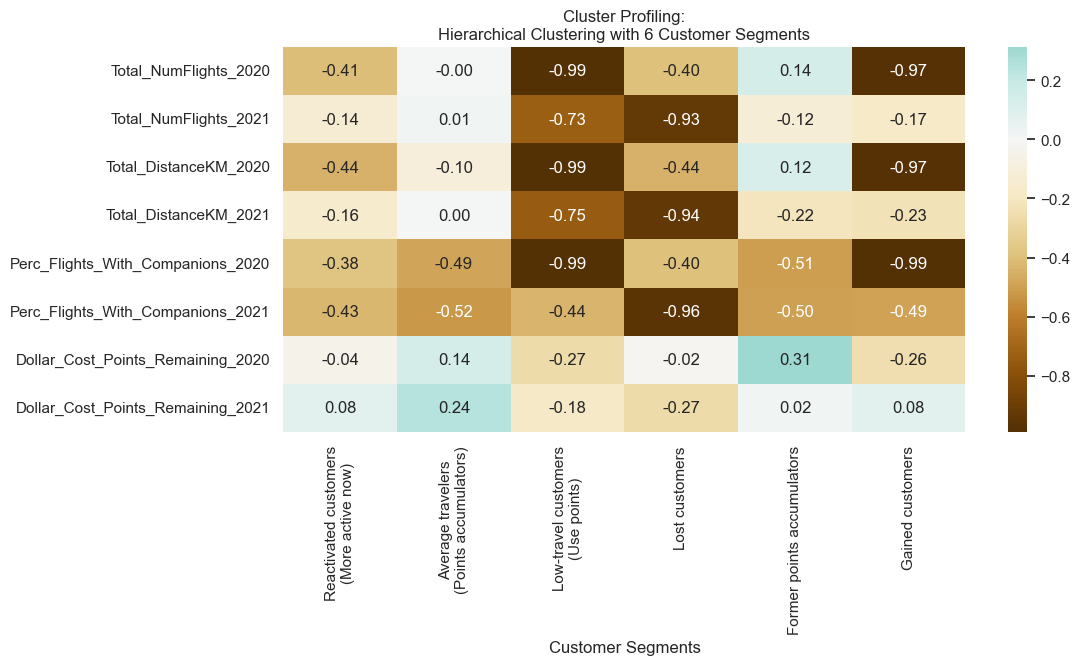

In [162]:
cluster_name_map_hc = {
    0: "Reactivated customers\n(More active now)",
    1: "Average travelers\n(Points accumulators)",
    2: "Low-travel customers\n(Use points)",
    3: "Lost customers",
    4: "Former points accumulators",
    5: "Gained customers"
}
df_concat_hc = pd.concat(
    (df_for_modeling, pd.Series(hc_labels, name='labels', index=df_for_modeling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(11, 5))

hc_profile = df_concat_hc.groupby('labels').mean().T

# Rename cluster columns with descriptive names
hc_profile = hc_profile.rename(columns=cluster_name_map_hc)

sns.heatmap(
    hc_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nHierarchical Clustering with 6 Customer Segments")
plt.show()

**Cluster Interpretations for Hierarchical Clustering with 6 Clusters:**

0. **Reactivated Customers**: Customers who were previously inactive or low-activity travelers but have become more engaged and active in recent periods.

1. **Average Travelers**: Stable customers with consistent average travel behavior, regularly accumulating points through their flights.

2. **Low-Travel Customers**: Individuals who travel infrequently and tend to rely on accumulated points for their limited trips.

3. **Lost Customers**: Formerly active travelers who have significantly reduced or stopped their travel activity.

4. **Former Points Accumulators**: Customers who previously focused on accumulating points but have shifted their behavior patterns.

5. **Gained Customers**: New or recently acquired travelers who have started engaging in travel activities, often at moderate levels.

In [163]:
df_concat_hc['cluster_name'] = df_concat_hc['labels'].map(cluster_name_map_hc)

In [164]:
df_concat_hc['cluster_name'].value_counts()

cluster_name
Average travelers\n(Points accumulators)    5418
Former points accumulators                  3305
Reactivated customers\n(More active now)    3008
Gained customers                            1477
Low-travel customers\n(Use points)          1229
Lost customers                               664
Name: count, dtype: int64

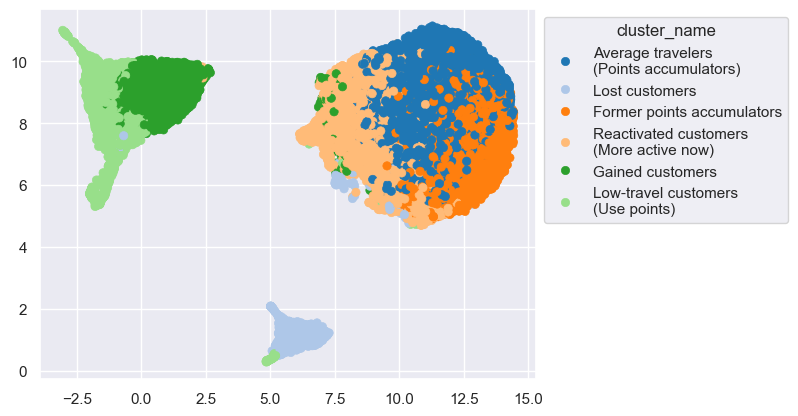

In [165]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat_hc['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Comparisons

In this section, the results obtained from the different clustering models are compared, specifically the KMeans models with 5 and 8 clusters and the Hierarchical Clustering model. The comparison evaluates their ability to segment customer behavior in terms of level of detail, interpretability, and practical usefulness, with the objective of selecting the most appropriate clustering approach for further analysis.

In [166]:
X = df_for_modeling.values

# Computing SST
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

# Computing SSW
ssw_iter = []                   # Outer summation
for i in np.unique(hc_labels):  # Loop for inner summation
    X_k = X[hc_labels == i]     # Data points belonging to cluster k
    inner_sum = np.sum(np.square(X_k - X_k.mean(axis=0)), axis=0)
    ssw_iter.append(inner_sum)  
ssw_per_feature = np.sum(ssw_iter, axis=0)  # Outer summation
ssw = np.sum(ssw_per_feature, axis=0)

# Computing SSB
ssb_iter = []
for i in np.unique(hc_labels):  # Loop for summation
    X_k = X[hc_labels == i]     # Data points belonging to cluster k
    ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))

ssb_per_feature = np.sum(ssb_iter, axis=0)
ssb = np.sum(ssb_per_feature, axis=0)

In [167]:
# Compare metrics between KMeans and Hierarchical Clustering
df_kmeans_selection = df_cluster_metrics.iloc[[3, 6]].copy()
df_kmeans_selection['Method'] = 'KMeans'


sil_hc = silhouette_score(X, hc_labels)

hc_row = pd.DataFrame([{
    'num_clusters': len(np.unique(hc_labels)),
    'ssw (Lower is better, 0 to +∞)': ssw,
    'ssb (Higher is better, 0 to SST)': ssb,
    'silhouette_score (Higher is better, −1 to +1)': sil_hc,
    'r2 (Higher is better, 0 to 1)': ssb / sst,
    'Method': 'Hierarchical'
}])

df_final_comparison = pd.concat([df_kmeans_selection, hc_row], ignore_index=True)

column_order = [
    'Method', 
    'num_clusters', 
    'r2 (Higher is better, 0 to 1)', 
    'silhouette_score (Higher is better, −1 to +1)',
    'ssw (Lower is better, 0 to +∞)',
    'ssb (Higher is better, 0 to SST)'
]

df_final_comparison = df_final_comparison[column_order]
display(df_final_comparison)

,Method,num_clusters,"r2 (Higher is better, 0 to 1)","silhouette_score (Higher is better, −1 to +1)","ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)"
0,KMeans,5,0.572619,0.192725,6170.571521,8267.509176
1,KMeans,8,0.646734,0.165211,5100.491436,9337.586982
2,Hierarchical,6,0.559739,0.125167,6356.524338,8081.542355


In [168]:
#  Create the Comparison DataFrame
df_comparison = pd.DataFrame({
    'Hierarchical': df_concat_hc['cluster_name'],
    'KMeans_5': df_concat_km5['cluster_name'],
    'KMeans_8': df_concat_km8['cluster_name']
}, index=df_for_modeling.index)


#  Create the Grouped Comparison Table
#clustering_comparison = df_comparison.groupby(['Hierarchical', 'KMeans_5', 'KMeans_8']).size().reset_index(name='Count')

clustering_comparison1 = df_comparison.groupby([ 'KMeans_5', 'KMeans_8']).size().reset_index(name='Count')
display(clustering_comparison1.set_index(['KMeans_5', 'KMeans_8']))

clustering_comparison2 = df_comparison.groupby([ 'KMeans_5', 'Hierarchical']).size().reset_index(name='Count')
display(clustering_comparison2.set_index(['KMeans_5', 'Hierarchical']))

clustering_comparison3 = df_comparison.groupby([ 'KMeans_8', 'Hierarchical']).size().reset_index(name='Count')
display(clustering_comparison3.set_index(['KMeans_8', 'Hierarchical']))


Count
KMeans_5                                           KMeans_8                                        
Gained customers\n(New travelers)                  Consistent low travelers\n(Use points)        16
                                                   Gained customers\n(Now traveling average)   1238
                                                   Growing travelers\n(Now average)              10
                                                   Low-travel individuals                      1225
Lost customers\n(Traveling much less now)          Consistent low travelers\n(Use points)        14
                                                   Growing travelers\n(Now average)              17
                                                   Lost custumers\n(Traveled more before)       635
                                                   Low-travel individuals                       248
Moderate travelers\n(Current average)              Consistent low travelers\n(Use points)       659
                                                   Gained customers\n(Now traveling average)    210
                                                   Growing travelers\n(Now average)             885
                                                   Lost custumers\n(Traveled more before)         2
                                                   Points accumulator currently\n(2021)        1678
Points accumulators\n(Loyal travelers)             Consistent low travelers\n(Use points)         3
                                                   Formers Points accumulator\n(2020)           484
                                                   Points accumulator currently\n(2021)        1260
                                                   Stable average travelers\n(Loyal)           2508
Previously average travelers\n(Traveling less now) Consistent low travelers\n(Use points)      1654
                                                   Formers Points accumulator\n(2020)          2197
                                                   Growing travelers\n(Now average)               2
                                                   Lost custumers\n(Traveled more before)        23
                                                   Points accumulator currently\n(2021)         132
                                                   Stable average travelers\n(Loyal)              1

Count
KMeans_5                                           Hierarchical                                   
Gained customers\n(New travelers)                  Gained customers                           1430
                                                   Lost customers                                7
                                                   Low-travel customers\n(Use points)          982
                                                   Reactivated customers\n(More active now)     70
Lost customers\n(Traveling much less now)          Former points accumulators                    3
                                                   Gained customers                              1
                                                   Lost customers                              607
                                                   Low-travel customers\n(Use points)          244
                                                   Reactivated customers\n(More active now)     59
Moderate travelers\n(Current average)              Average travelers\n(Points accumulators)   1100
                                                   Former points accumulators                   31
                                                   Gained customers                             46
                                                   Lost customers                                3
                                                   Low-travel customers\n(Use points)            2
                                                   Reactivated customers\n(More active now)   2252
Points accumulators\n(Loyal travelers)             Average travelers\n(Points accumulators)   3075
                                                   Former points accumulators                 1122
                                                   Reactivated customers\n(More active now)     58
Previously average travelers\n(Traveling less now) Average travelers\n(Points accumulators)   1243
                                                   Former points accumulators                 2149
                                                   Lost customers                               47
                                                   Low-travel customers\n(Use points)            1
                                                   Reactivated customers\n(More active now)    569

Count
KMeans_8                                  Hierarchical                                   
Consistent low travelers\n(Use points)    Average travelers\n(Points accumulators)    741
                                          Former points accumulators                  488
                                          Gained customers                              2
                                          Lost customers                               22
                                          Low-travel customers\n(Use points)            3
                                          Reactivated customers\n(More active now)   1090
Formers Points accumulator\n(2020)        Average travelers\n(Points accumulators)    651
                                          Former points accumulators                 2001
                                          Lost customers                                9
                                          Reactivated customers\n(More active now)     20
Gained customers\n(Now traveling average) Average travelers\n(Points accumulators)      3
                                          Gained customers                           1224
                                          Low-travel customers\n(Use points)           11
                                          Reactivated customers\n(More active now)    210
Growing travelers\n(Now average)          Average travelers\n(Points accumulators)    103
                                          Lost customers                                1
                                          Low-travel customers\n(Use points)            2
                                          Reactivated customers\n(More active now)    808
Lost custumers\n(Traveled more before)    Former points accumulators                    4
                                          Lost customers                              614
                                          Low-travel customers\n(Use points)           16
                                          Reactivated customers\n(More active now)     26
Low-travel individuals                    Gained customers                            250
                                          Lost customers                               18
                                          Low-travel customers\n(Use points)         1197
                                          Reactivated customers\n(More active now)      8
Points accumulator currently\n(2021)      Average travelers\n(Points accumulators)   2146
                                          Former points accumulators                   78
                                          Gained customers                              1
                                          Reactivated customers\n(More active now)    845
Stable average travelers\n(Loyal)         Average travelers\n(Points accumulators)   1774
                                          Former points accumulators                  734
                                          Reactivated customers\n(More active now)      1

The clustering models show differences mainly in the level of detail and interpretability. The KMeans model with 5 clusters provides a simple and clear segmentation, suitable for a general overview of customer behavior. The KMeans model with 8 clusters offers a more detailed breakdown, capturing finer differences in travel frequency and points accumulation. The hierarchical clustering model helps illustrate relationships between customer groups but is less practical for direct segmentation.

Based on the comparative analysis of the K-Means (k=5, k=8) and Hierarchical Clustering models, the K-Means model with 8 clusters was selected for the final implementation. 

This configuration provides the optimal balance across key performance metrics:

 - Cluster Quality: The Silhouette Score is good, similar to the others.

 - Variance Explained: It achieved the highest $R^2$ value, meaning a greater proportion of the total dataset variance is captured by the cluster structure.

 - Model Efficiency: The model demonstrated a lower Within-Cluster Sum of Squares (SSW) and a higher Between-Cluster Sum of Squares (SSB). 

This confirms that the clusters are internally compact and geographically distinct from one another, outperforming both the 5-cluster K-Means and the Hierarchical approach."

## Conclusions

Several clustering models were evaluated using quantitative performance metrics and interpretability. The KMeans model with 8 clusters was selected as the final model because it provides the strongest overall results.

The KMeans model with 8 clusters achieves a better balance between clustering quality and interpretability, making it the most suitable choice for this analysis.

In [169]:
# Rename the column in the original DataFrame 
df_concat_km8 = df_concat_km8.rename(columns={'cluster_name': 'Behavioral_Year_Cluster_Name'})

behavioral_csv = df_concat_km8[['Behavioral_Year_Cluster_Name']]

In [170]:
behavioral_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15101 entries, 480934 to 615459
Data columns (total 1 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Behavioral_Year_Cluster_Name  15101 non-null  object
dtypes: object(1)
memory usage: 236.0+ KB


We need to add our No Transaction group to the final cluster

In [171]:
behavioral_csv = pd.concat([behavioral_csv, df_AIAI_Y_Behavioral_classified[['Final_Cluster']].rename(columns={'Final_Cluster': 'Behavioral_Year_Cluster_Name'})], axis=0)

In [172]:
behavioral_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 1 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Behavioral_Year_Cluster_Name  16572 non-null  object
dtypes: object(1)
memory usage: 258.9+ KB


In [175]:
behavioral_csv.to_csv("behavioral_clusters_year.csv", index=True)
print("CSV file created: behavioral_clusters_year.csv")

CSV file created: behavioral_clusters_year.csv


In [176]:
behavioral_csv.head()

,Behavioral_Year_Cluster_Name
Loyalty#,
480934,Stable average travelers\n(Loyal)
549612,Formers Points accumulator\n(2020)
429460,Lost custumers\n(Traveled more before)
608370,Formers Points accumulator\n(2020)
530508,Points accumulator currently\n(2021)
